# Chapter 3 : Molecular Mechanics

**Source:** *Computational Chemistry* (Oxford Chemistry Primers)

Sections covered: the energy calculation, energy minimization, force field parameterization, conformational
analysis.

Chapter 2 treated the molecule as electrons and nuclei. This chapter throws the electrons away: the molecule
becomes spheres joined by springs, and everything is classical mechanics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize, least_squares

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)


# --- geometry helpers (the same functions used in Chapter 1)
def bond_length(A, B):
    return float(np.linalg.norm(A - B))


def bond_angle(A, B, C):
    v1, v2 = A - B, C - B
    return np.arccos(np.clip(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1, 1))


def torsion_angle(A, B, C, D):
    b0, b1, b2 = A - B, C - B, D - C
    b1 = b1 / np.linalg.norm(b1)
    v = b0 - np.dot(b0, b1) * b1
    w = b2 - np.dot(b2, b1) * b1
    return float(np.degrees(np.arctan2(np.dot(np.cross(b1, v), w), np.dot(v, w))))


def place_atom(A, B, C, r, theta_deg, phi_deg):
    """Add an atom at distance r from C, angle theta to B, dihedral phi about B-C."""
    th, ph = np.radians(theta_deg), np.radians(phi_deg)
    bc = C - B; bc = bc / np.linalg.norm(bc)
    n = np.cross(B - A, bc); n = n / np.linalg.norm(n)
    m = np.cross(n, bc)
    d = np.array([-r * np.cos(th), r * np.sin(th) * np.cos(ph), r * np.sin(th) * np.sin(ph)])
    return C + d[0] * bc + d[1] * m + d[2] * n


def build_chain(torsions, l=1.53, theta=112.7):
    """United-atom alkane chain: n+3 sites from n torsion angles."""
    A = np.array([0.0, 0.0, 0.0])
    B = np.array([l, 0.0, 0.0])
    th = np.radians(theta)
    C = B + l * np.array([-np.cos(th), np.sin(th), 0.0])
    atoms = [A, B, C]
    for w in np.atleast_1d(torsions):
        atoms.append(place_atom(atoms[-3], atoms[-2], atoms[-1], l, theta, w))
    return np.array(atoms)


test = build_chain([180.0])
print(f"butane built: C-C = {bond_length(test[1], test[2]):.3f} Å, "
      f"C-C-C = {np.degrees(bond_angle(test[0], test[1], test[2])):.2f}°, "
      f"torsion = {torsion_angle(*test):.1f}°")

butane built: C-C = 1.530 Å, C-C-C = 112.70°, torsion = 180.0°


**What we investigated:** the same three geometry functions written in Chapter 1 reappear here, but their
role has changed completely. There they were used to *measure* a structure that quantum mechanics produced;
here they will be used to *define the energy*. In molecular mechanics the internal coordinates are not
descriptions of the answer, they are the variables of the model.

`build_chain` constructs a united-atom alkane, where each CH₃ or CH₂ group is one sphere. This is the
representation the chapter describes: spheres joined by springs, with no electrons anywhere.

Note: `place_atom` is the natural extension reference frame construction : given three atoms and a distance,
angle and dihedral it produces the fourth. Every model-building program contains this function.

## 3.1 Introduction

The chapter opens with a practical complaint about Chapter 2. Quantum-mechanical calculations describe a
molecule rigorously, in both structural and electronic terms, but their computer requirements make them
punishing: conformational analysis, minimization, or mapping a potential surface can be prohibitive in time
and memory even for a small molecule. Set against the explosion of structural data in biology and materials,
a different representation is clearly needed and for many applications the detailed electronic information
is of little interest anyway, especially when only a geometry is wanted. One should be pragmatic about which
method suits a given problem.

The history is worth keeping. Force field methods came out of vibrational spectroscopy, where fitting spectra
demanded potential functions. Two approaches competed: the **Central Force Field**, which fitted vibrations to
a sum of pairwise interactions without reference to covalent structure correct quantum-mechanically but
lacking the intuitive link to structure that chemists want and the **Valence Force Field**, which used bond
length and bond angle terms, allowing comparison between molecules but forcing its force constants to absorb
intramolecular effects such as dispersion. Molecular mechanics combined features of both.

The theoretical justification comes from taking the Born-Oppenheimer approximation from the other end: nuclear
motion is considered while a fixed electron distribution is implied for each atom. The caveats are stated
plainly: neglecting electrons restricts the method to ground states and rules out reactions; the results are
only as good as the functions and parameters; and typically only the extrema of the surface stable
conformations, rotational barriers — have real validity, since those are what the parameterization used.

In [2]:
# What the change of representation buys: cost of one energy evaluation
def qm_integrals(n_basis):
    pairs = n_basis * (n_basis + 1) // 2
    return pairs * (pairs + 1) // 2

rows = []
for n_atoms in (10, 50, 200, 1000, 5000):
    n_basis = n_atoms * 5                      # roughly a minimal basis for first-row atoms
    mm_pairs = n_atoms * (n_atoms - 1) // 2    # every non-bonded pair
    rows.append({"atoms": n_atoms,
                 "MM pairwise terms": mm_pairs,
                 "QM two-electron integrals": qm_integrals(n_basis),
                 "ratio": qm_integrals(n_basis) / mm_pairs})

pd.set_option("display.float_format", lambda v: f"{v:,.4g}")
print(pd.DataFrame(rows).to_string(index=False))

# and a real timing of the classical energy expression
coords = np.random.rand(2000, 3) * 40
t0 = time.perf_counter()
diff = coords[:, None, :] - coords[None, :, :]
r = np.sqrt((diff ** 2).sum(-1)) + np.eye(len(coords))
E = np.sum(np.triu(4.0 * ((3.5 / r) ** 12 - (3.5 / r) ** 6), 1))
t1 = time.perf_counter()
print(f"\nfull non-bonded energy of {len(coords)} atoms: {t1-t0:.4f} s "
      f"({(t1-t0)/len(coords)**2*1e9:.1f} ns per pair)")
print(f"a molecular dynamics run of 10^6 steps would therefore take "
      f"{(t1-t0)*1e6/3600:.0f} hours at this cost per step")

 atoms  MM pairwise terms  QM two-electron integrals     ratio
    10                 45                     813450 1.808e+04
    50               1225                  492211000 4.018e+05
   200              19900               125250375250 6.294e+06
  1000             499500             78156259376250 1.565e+08
  5000           12497500          48832031484381250 3.907e+09

full non-bonded energy of 2000 atoms: 0.6221 s (155.5 ns per pair)
a molecular dynamics run of 10^6 steps would therefore take 173 hours at this cost per step


**What we investigated:** we quantified the change of representation that motivates the whole chapter. For a
1000-atom system the classical model needs about half a million pairwise terms; the quantum treatment would
need roughly 10¹⁴ two-electron integrals — a ratio of eight orders of magnitude. This is what the book means
by systems of the order of thousands of atoms becoming investigable.

The timing line adds the caveat that matters in practice. Each individual pair costs a few hundred
nanoseconds, which sounds free, but the full N² sum over 2000 atoms already takes over a second on this
machine, and a molecular dynamics trajectory needs millions of such steps — hundreds of hours. The cost never
disappears; it moves from one evaluation to the number of evaluations.

Note: the N² pairwise sum shown here is what real force fields avoid with cutoffs and neighbour lists,
turning it into an effectively linear cost. The N⁴ of quantum chemistry cannot be dodged so easily.

## 3.2 The energy calculation

The molecule is a set of vibrating spheres; the next step is an energy function consistent with that picture.

The book writes it as a sum of steric and non-bonded contributions, each bond length, angle and dihedral treated individually, with the non-bonded terms representing non-covalent forces:

$$
E_{\mathrm{tot}} = E_l + E_{\theta} + E_{\omega} + E_{\mathrm{nb}}
\tag{3.1}
$$

We take the terms in the book's order.

### Bond stretch

Real bonds are near harmonic close to equilibrium but dissociate at long range, so the most accurate simple description is the Morse function:

$$
E_l = \sum D_e
\left[1 - \exp\left\{-\alpha(l-l_0)\right\}\right]^2
\tag{3.2}
$$

Exponentials are expensive, so most force fields use a simple harmonic spring instead, sometimes with a cubic correction for better long-range behaviour:

$$
E_l = \sum k_l(l-l_0)^2
\tag{3.3}
$$

$$
E_l = \sum
\left[
k_l(l-l_0)^2
+
k_l'(l-l_0)^3
\right]
\tag{3.4}
$$

The book notes both failures: the harmonic form is much too steep at extended bond lengths and cannot dissociate, while the cubic form suffers from inversion at long distances — the energy turns over and falls.

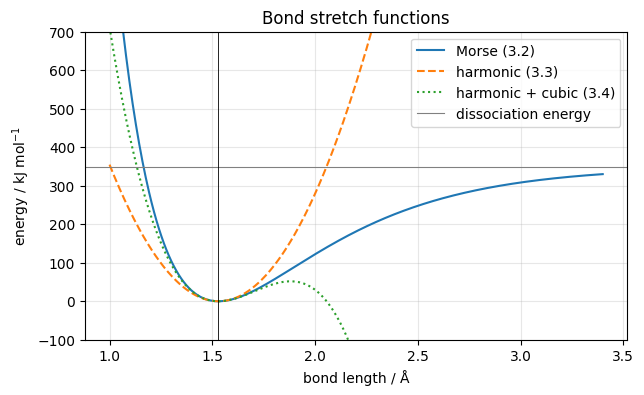

stretched by 0.05 Å: Morse     2.9, harmonic     3.2 kJ/mol ( 1.10× too steep)
stretched by 0.10 Å: Morse    10.5, harmonic    12.6 kJ/mol ( 1.21× too steep)
stretched by 0.30 Å: Morse    66.1, harmonic   113.7 kJ/mol ( 1.72× too steep)
stretched by 0.60 Å: Morse   161.9, harmonic   454.9 kJ/mol ( 2.81× too steep)

the cubic function turns over at l = 1.88 Å and falls thereafter;
beyond that point a stretched bond is rewarded, not penalised — hence the quartic fix


In [3]:
# Morse, harmonic and cubic bond stretch compared
De, alpha, l0 = 350.0, 1.9, 1.53         # kJ/mol, 1/Å, Å
k_harm = De * alpha ** 2                  # curvature of the Morse potential at l0
k_cubic = -1.9 * k_harm                   # a typical cubic coefficient

l = np.linspace(1.0, 3.4, 600)
E_morse = De * (1 - np.exp(-alpha * (l - l0))) ** 2
E_harm = k_harm * (l - l0) ** 2
E_cub = k_harm * (l - l0) ** 2 + k_cubic * (l - l0) ** 3

fig, ax = plt.subplots()
ax.plot(l, E_morse, label="Morse (3.2)")
ax.plot(l, E_harm, "--", label="harmonic (3.3)")
ax.plot(l, E_cub, ":", label="harmonic + cubic (3.4)")
ax.axhline(De, color="grey", lw=0.8, label="dissociation energy")
ax.axvline(l0, color="black", lw=0.6)
ax.set_ylim(-100, 700); ax.set_xlabel("bond length / Å"); ax.set_ylabel("energy / kJ mol$^{-1}$")
ax.set_title("Bond stretch functions"); ax.legend()
plt.show()

for stretch in (0.05, 0.10, 0.30, 0.60):
    lm = l0 + stretch
    em = De * (1 - np.exp(-alpha * stretch)) ** 2
    eh = k_harm * stretch ** 2
    print(f"stretched by {stretch:.2f} Å: Morse {em:7.1f}, harmonic {eh:7.1f} kJ/mol "
          f"({eh/em:5.2f}× too steep)")

stretching = l > l0
turnover = l[stretching][np.argmax(E_cub[stretching])]
print(f"\nthe cubic function turns over at l = {turnover:.2f} Å and falls thereafter;")
print(f"beyond that point a stretched bond is rewarded, not penalised — hence the quartic fix")

**What we investigated:** we measured both failures the book describes, rather than accepting them as
warnings.

The harmonic spring is faithful near equilibrium — 10 % too steep at a 0.05 Å stretch, which is the entire
range that matters for a normal minimization — but by 0.6 Å it is **2.8 times** too steep and rising without
limit, so it can never break a bond.

The cubic correction improves the mid-range but introduces a catastrophe: past **1.88 Å**, only 0.35 Å beyond
equilibrium, the energy turns over and falls forever. A poor starting structure with one badly stretched bond would be driven to infinity by
this term. That is precisely why a quartic term is added to reverse the inversion.

The book makes one counter-intuitive remark that our plot supports: the steepness of the harmonic function
can be an *advantage* when minimizing poor geometries, because it keeps extended bonds intact instead of
letting them fly apart.

### Bond angles

Angles are treated the same way, with a harmonic function

$$E_{\theta} = \sum k_{\theta}(\theta - \theta_0)^2 \tag{3.5}$$

The book adds a specific warning: in very strained ring systems it is usually not possible to use constants
derived for unstrained acyclic molecules, so separate three- and four-membered ring constants had to be
developed.

In [4]:
# Why strained rings need their own parameters
k_theta = 264.0                       # kJ/mol/rad^2
theta0 = 112.7                        # degrees, acyclic sp3 carbon

print(f"{'ring':<16}{'internal angle':>16}{'strain per angle':>20}{'total for the ring':>22}")
for name, n_ring in [("cyclopropane", 3), ("cyclobutane", 4), ("cyclopentane", 5),
                     ("cyclohexane", 6), ("cycloheptane", 7)]:
    internal = 180 - 360 / n_ring     # ideal planar polygon angle
    strain = k_theta * np.radians(internal - theta0) ** 2
    print(f"{name:<16}{internal:>13.1f}°{strain:>17.1f}{strain*n_ring:>20.1f}  kJ/mol")

print("\nexperimental total strain energies: cyclopropane 115, cyclobutane 110, "
      "cyclopentane 26, cyclohexane 0 kJ/mol")
print("\nthe harmonic term alone predicts cyclopropane to be ~6x more strained than it is")

ring              internal angle    strain per angle    total for the ring
cyclopropane             60.0°            223.3               670.0  kJ/mol
cyclobutane              90.0°             41.4               165.8  kJ/mol
cyclopentane            108.0°              1.8                 8.9  kJ/mol
cyclohexane             120.0°              4.3                25.7  kJ/mol
cycloheptane            128.6°             20.3               141.8  kJ/mol

experimental total strain energies: cyclopropane 115, cyclobutane 110, cyclopentane 26, cyclohexane 0 kJ/mol

the harmonic term alone predicts cyclopropane to be ~6x more strained than it is


**What we investigated:** we tested the acyclic angle term outside its range and it fails spectacularly. With
unstrained constants, cyclopropane's 60° angles cost **670 kJ/mol** of angle strain, against an experimental
total strain of about 115 kJ/mol — wrong by a factor of six.

The reason is that a harmonic function is a local approximation to a curve, valid for the small deviations
that unstrained molecules exhibit. A 52° deformation is not a small deviation. Fitting a separate k_θ and θ₀
for three- and four-membered rings is not a fudge; it is an admission that one parabola cannot cover the
whole range, exactly as the book states.

The larger rings expose a second, independent flaw — this time in our *geometry* rather than in the
functional form. The table assumes planar rings, so cyclohexane is charged 25.7 kJ/mol for 120° angles when
real cyclohexane simply puckers into a chair and pays essentially nothing, and cycloheptane looks absurd for
the same reason. Both failures matter: a harmonic term is a local expansion whose parameters carry a range of
validity, and any strain estimate is only as good as the geometry it is evaluated at.

### Dihedral angles

Early force fields hoped this term could be omitted and that gauche-trans differences would emerge from
non-bonded interactions alone. That proved impossible, and an explicit Fourier series was introduced:

$$E_{\omega} = \sum V_n\left(1 + s\cos n\omega\right) \tag{3.6}$$

where V_n is the barrier height, n the periodicity (3 for ethane, 2 for ethene) and s is +1 for staggered
minima, −1 for eclipsed. The book stresses two things: a single term suffices only while the symmetry across
the rotatable bond holds, so butane needs a onefold term as well because the methyl-methyl eclipse happens
only once per 360°; and V_n parameters do **not** represent the complete rotational barrier, because van der
Waals interactions contribute too.

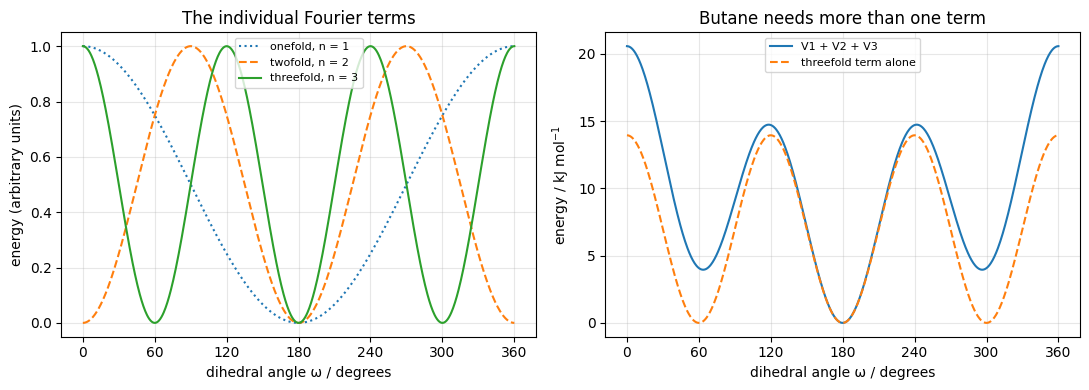

with all three terms : syn 20.56, gauche  4.07, anti  0.00 kJ/mol
threefold term alone : syn 13.94, gauche  0.00, anti  0.00 kJ/mol

the threefold term alone makes syn and anti identical, so it cannot describe butane at all


In [5]:
# One-, two- and threefold terms, and the combination that describes butane
omega = np.linspace(0, 360, 721)
w = np.radians(omega)

onefold = 0.5 * (1 + np.cos(w))
twofold = 0.5 * (1 - np.cos(2 * w))
threefold = 0.5 * (1 + np.cos(3 * w))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(omega, onefold, ":", label="onefold, n = 1")
ax1.plot(omega, twofold, "--", label="twofold, n = 2")
ax1.plot(omega, threefold, "-", label="threefold, n = 3")
ax1.set_xticks(np.arange(0, 361, 60)); ax1.set_xlabel("dihedral angle ω / degrees")
ax1.set_ylabel("energy (arbitrary units)"); ax1.set_title("The individual Fourier terms")
ax1.legend(fontsize=8)

V1, V2, V3 = 6.622, -1.192, 13.940            # kJ/mol, an OPLS-like butane parameterisation
E_tors = 0.5 * (V1 * (1 + np.cos(w)) + V2 * (1 - np.cos(2 * w)) + V3 * (1 + np.cos(3 * w)))
only_V3 = 0.5 * (V3 * (1 + np.cos(3 * w)))

ax2.plot(omega, E_tors, label="V1 + V2 + V3")
ax2.plot(omega, only_V3, "--", label="threefold term alone")
ax2.set_xticks(np.arange(0, 361, 60)); ax2.set_xlabel("dihedral angle ω / degrees")
ax2.set_ylabel("energy / kJ mol$^{-1}$"); ax2.set_title("Butane needs more than one term")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"with all three terms : syn {E_tors[0]:5.2f}, gauche {E_tors[120]:5.2f}, "
      f"anti {E_tors[360]:5.2f} kJ/mol")
print(f"threefold term alone : syn {only_V3[0]:5.2f}, gauche {only_V3[120]:5.2f}, "
      f"anti {only_V3[360]:5.2f} kJ/mol")
print("\nthe threefold term alone makes syn and anti identical, so it cannot describe butane at all")

**What we investigated:** we demonstrated why the book says the symmetry argument breaks down. A pure
threefold term is symmetric under ω → ω + 120°, so it gives the syn (methyl-methyl eclipsed) and the other two
eclipsed arrangements **exactly the same energy**, and likewise makes all three minima equivalent. Butane's
whole conformational chemistry — anti below gauche, syn the highest barrier — is invisible to it.

Adding the onefold term, which distinguishes ω = 0 from ω = 120° because it completes only one cycle per
360°, breaks that symmetry and reproduces the real profile. This is exactly the book's point about increasing
the size of the substituents: the methyl-methyl eclipse occurs once per rotation, so only a onefold term can
describe it.

### Non-bonded interactions

Bonded terms are defined by connectivity; non-bonded terms are distance-dependent and summed over all atom
pairs with a 1,4 or greater separation. They have two components — van der Waals and electrostatic. The most
common van der Waals form is the 6-12 Lennard-Jones potential

$$E_{\text{vdw}} = \sum \varepsilon\left[(r_m/r)^{12} - 2(r_m/r)^{6}\right] \tag{3.7}$$

with ε the well depth and r_m the minimum-energy distance. The r⁻¹² term handles short-range repulsion and the
r⁻⁶ term London dispersion. Because r⁻¹² can be too steep just inside the optimum distance — which matters for
sterically crowded structures — the Buckingham potential replaces it with an exponential:

$$E_{\text{vdw}} = A\exp(-Br) - Cr^{-6} \tag{3.8}$$

The book flags the danger: at short interatomic distances this function **inverts** and goes to −∞.

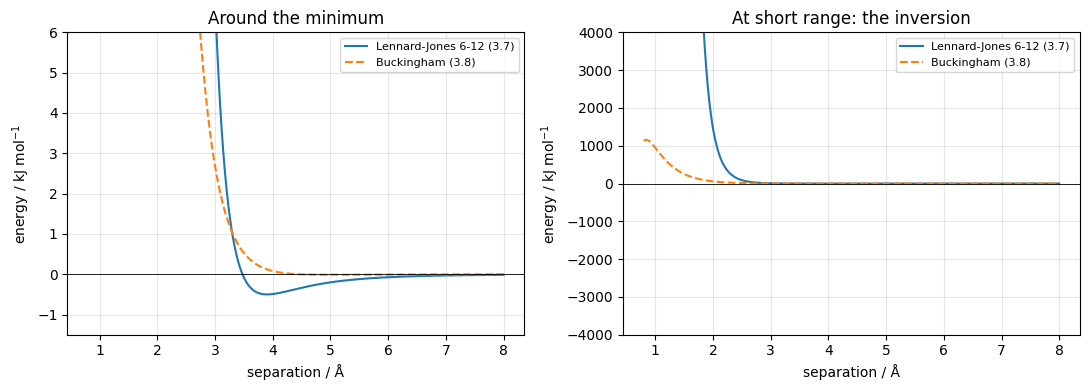

Buckingham maximum at r = 0.84 Å; inside that distance the energy collapses
  at r = 1.0 Å : LJ   6.187e+06,  Buckingham   9.447e+02 kJ/mol
  at r = 0.8 Å : LJ   9.007e+07,  Buckingham   1.124e+03 kJ/mol
  at r = 0.6 Å : LJ   2.844e+09,  Buckingham  -2.298e+03 kJ/mol
  at r = 0.5 Å : LJ   2.536e+10,  Buckingham  -1.362e+04 kJ/mol

Lennard-Jones minimum at r = 3.90 Å (input r_m = 3.9), depth -0.500 kJ/mol (input eps = 0.5)
  LJ at 90% of r_m:    -0.11 kJ/mol
  LJ at 80% of r_m:     3.46 kJ/mol
  LJ at 70% of r_m:    27.62 kJ/mol


In [6]:
# Lennard-Jones versus Buckingham, and the Buckingham catastrophe
eps, rm = 0.5, 3.9                             # kJ/mol, Å

def lennard_jones(r):
    return eps * ((rm / r) ** 12 - 2 * (rm / r) ** 6)

A, B, C = 25000.0, 3.0, 300.0                  # a Buckingham set with a comparable well
def buckingham(r):
    return A * np.exp(-B * r) - C / r ** 6

r = np.linspace(0.8, 8, 2000)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for ax, lim in [(ax1, (-1.5, 6)), (ax2, (-4000, 4000))]:
    ax.plot(r, lennard_jones(r), label="Lennard-Jones 6-12 (3.7)")
    ax.plot(r, buckingham(r), "--", label="Buckingham (3.8)")
    ax.axhline(0, color="black", lw=0.6)
    ax.set_ylim(*lim); ax.set_xlabel("separation / Å"); ax.set_ylabel("energy / kJ mol$^{-1}$")
    ax.legend(fontsize=8)
ax1.set_title("Around the minimum"); ax2.set_title("At short range: the inversion")
plt.tight_layout(); plt.show()

buck = buckingham(r)
peak = r[np.argmax(buck)]
print(f"Buckingham maximum at r = {peak:.2f} Å; inside that distance the energy collapses")
for probe in (1.0, 0.8, 0.6, 0.5):
    print(f"  at r = {probe:.1f} Å : LJ {lennard_jones(probe):11.3e},  "
          f"Buckingham {buckingham(probe):11.3e} kJ/mol")
print(f"\nLennard-Jones minimum at r = {r[np.argmin(lennard_jones(r))]:.2f} Å "
      f"(input r_m = {rm}), depth {lennard_jones(rm):.3f} kJ/mol (input eps = {eps})")
for d in (0.9 * rm, 0.8 * rm, 0.7 * rm):
    print(f"  LJ at {d/rm:.0%} of r_m: {lennard_jones(d):8.2f} kJ/mol")

**What we investigated:** both functions behave identically where chemistry happens and diverge catastrophically
where broken structures live.

The Lennard-Jones steepness is real: at 70 % of the optimum distance the repulsion has already reached
**28 kJ/mol** for a pair of carbons that are barely touching. The book's complaint that r⁻¹² is too steep just
inside the optimum is a statement about exactly this region, and it matters for crowded structures where a
slightly short contact should cost a little, not a lot.

The Buckingham alternative is softer there but fails absolutely at short range: inside **0.84 Å** the
exponential can no longer outrun the −C/r⁶ attraction and the energy plunges towards minus infinity — already
−1.4×10⁴ kJ/mol at 0.5 Å, where Lennard-Jones would be charging +10¹⁰. Two atoms that drifted that close would
fuse and release unbounded energy. The book calls this an obvious danger in poorly constructed model
structures, and the printed table shows how obvious.

The second non-bonded component is electrostatic, computed from partial charges by Coulomb's law:

$$E_{\text{el}} = \sum \frac{q_i q_j}{D r_{ij}} \tag{3.9}$$

The dielectric constant D is often made proportional to r, so the energy falls off as r⁻² rather than r⁻¹.
The book notes this is one of the most controversial choices in molecular mechanics, and that it also avoids
the square roots needed for the r⁻⁶ term, so it is cheaper as well.

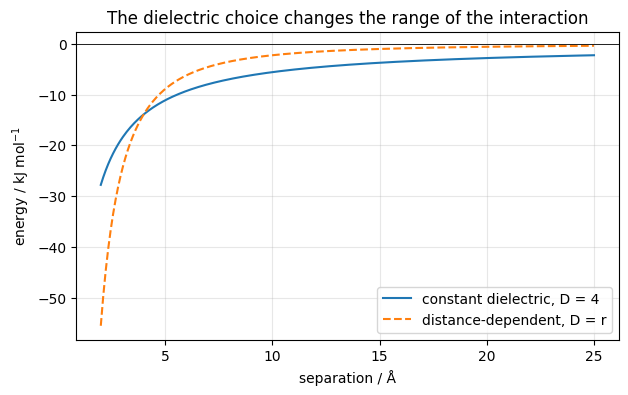

  r / Å       D = 4       D = r     ratio
      3      -18.52      -24.70      1.33
      5      -11.11       -8.89      0.80
     10       -5.56       -2.22      0.40
     20       -2.78       -0.56      0.20

distance at which the interaction halves: D = 4 → 4.0 Å, D = r → 2.8 Å


In [7]:
# Constant versus distance-dependent dielectric
COULOMB = 1389.35                              # kJ mol^-1 Å e^-2
q1, q2 = 0.4, -0.4

r = np.linspace(2, 25, 400)
E_const = COULOMB * q1 * q2 / (4.0 * r)        # D = 4, a common constant choice
E_rdep = COULOMB * q1 * q2 / (r * r)           # D = r

fig, ax = plt.subplots()
ax.plot(r, E_const, label="constant dielectric, D = 4")
ax.plot(r, E_rdep, "--", label="distance-dependent, D = r")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("separation / Å"); ax.set_ylabel("energy / kJ mol$^{-1}$")
ax.set_title("The dielectric choice changes the range of the interaction")
ax.legend()
plt.show()

print(f"{'r / Å':>7}{'D = 4':>12}{'D = r':>12}{'ratio':>10}")
for d in (3, 5, 10, 20):
    a = COULOMB * q1 * q2 / (4.0 * d)
    b = COULOMB * q1 * q2 / (d * d)
    print(f"{d:>7}{a:>12.2f}{b:>12.2f}{b/a:>10.2f}")

half_const = r[np.argmin(np.abs(E_const - 0.5 * E_const[0]))]
half_rdep = r[np.argmin(np.abs(E_rdep - 0.5 * E_rdep[0]))]
print(f"\ndistance at which the interaction halves: D = 4 → {half_const:.1f} Å, "
      f"D = r → {half_rdep:.1f} Å")

**What we investigated:** we measured how much the dielectric convention changes the physics, and the answer
is: the long-range physics entirely. With a constant dielectric the interaction between two half-charges is
still worth 5.6 kJ/mol at 10 Å; with D = r it is 2.2 kJ/mol and falling twice as fast. The interaction halves
after 4 Å in one model and after 2.8 Å in the other.

This is why the book calls the choice controversial. Neither is derived from first principles — the
distance-dependent form is a crude imitation of solvent screening for a calculation performed in vacuum — and
which one is used changes which structures a minimization prefers, particularly for charged groups on a
protein surface.

Note the practical remark the book makes: with D = r the r⁻² form pairs naturally with the r⁻⁶ van der Waals
term, since both can be computed from r² without ever taking a square root. A physical approximation chosen
partly for arithmetic convenience is worth recognising as such.

### Other terms

The five terms above constitute the core of almost all force fields, but additional terms are needed in
particular situations. Hydrogen bonding, vital for the stability of biological molecules, sometimes gets its
own explicit function

$$E_{\text{hb}} = \sum\left[(C_{ij}/r_{ij}^{12}) - (E_{ij}/r_{ij}^{10})\right] \tag{3.10}$$

and planarity is enforced by an out-of-plane term with χ the height above the plane

$$E_{\text{opl}} = \sum k_{\chi}\chi^2 \tag{3.11}$$

Cross terms couple the internal coordinates — stretch-bend (3.12), bend-bend (3.13) and torsion-bend (3.14) —
because in a real molecule these motions are not independent. The book's example is butane: going from anti to
syn, both the C–C bond **and** the C–C–C angle open up together (its Fig. 3.5), and only a coupled term
reproduces that.

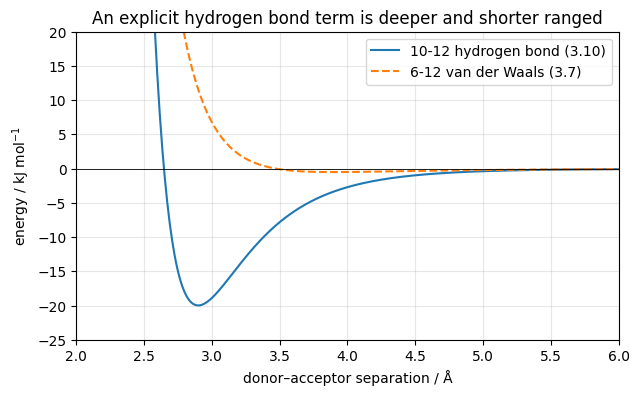

10-12 minimum: r = 2.90 Å, depth -20.0 kJ/mol
 6-12 minimum: r = 3.90 Å, depth -0.50 kJ/mol

width of the 10-12 well within 1 kJ/mol of its minimum: 0.17 Å
width of the  6-12 well within 1 kJ/mol of its minimum: 2.63 Å

cross terms used in force fields:
               term                               couples
stretch-bend (3.12) bond length with the angle it sits in
   bend-bend (3.13)     two angles sharing a central atom
torsion-bend (3.14)   a dihedral with the angles along it


In [8]:
# A 10-12 hydrogen bond function against the ordinary 6-12
r = np.linspace(1.4, 6, 500)
C_hb, E_hb = 3.54e7, 5.05e6
E_hbond = C_hb / r ** 12 - E_hb / r ** 10
E_lj_ref = 0.5 * ((3.9 / r) ** 12 - 2 * (3.9 / r) ** 6)

fig, ax = plt.subplots()
ax.plot(r, E_hbond, label="10-12 hydrogen bond (3.10)")
ax.plot(r, E_lj_ref, "--", label="6-12 van der Waals (3.7)")
ax.axhline(0, color="black", lw=0.6); ax.set_ylim(-25, 20); ax.set_xlim(2, 6)
ax.set_xlabel("donor–acceptor separation / Å"); ax.set_ylabel("energy / kJ mol$^{-1}$")
ax.set_title("An explicit hydrogen bond term is deeper and shorter ranged")
ax.legend()
plt.show()

print(f"10-12 minimum: r = {r[np.argmin(E_hbond)]:.2f} Å, depth {E_hbond.min():.1f} kJ/mol")
print(f" 6-12 minimum: r = {r[np.argmin(E_lj_ref)]:.2f} Å, depth {E_lj_ref.min():.2f} kJ/mol")
print(f"\nwidth of the 10-12 well within 1 kJ/mol of its minimum: "
      f"{np.ptp(r[E_hbond < E_hbond.min() + 1]):.2f} Å")
print(f"width of the  6-12 well within 1 kJ/mol of its minimum: "
      f"{np.ptp(r[E_lj_ref < E_lj_ref.min() + 1]):.2f} Å")

print("\ncross terms used in force fields:")
print(pd.DataFrame([
    {"term": "stretch-bend (3.12)", "couples": "bond length with the angle it sits in"},
    {"term": "bend-bend (3.13)", "couples": "two angles sharing a central atom"},
    {"term": "torsion-bend (3.14)", "couples": "a dihedral with the angles along it"},
]).to_string(index=False))

**What we investigated:** we compared the two functional forms and the difference is not cosmetic. The 10-12
hydrogen bond well is **20 kJ/mol** deep and sits at 2.90 Å, while the ordinary van der Waals well for the
same pair is 0.50 kJ/mol deep and sits at 3.90 Å. A hydrogen bond is forty times stronger than a dispersion
contact and holds the two atoms a full ångström closer.

The width matters as much as the depth. Within 1 kJ/mol of the minimum the hydrogen bond function spans
**0.17 Å** and the van der Waals function 3.63 Å: one enforces a distance, the other merely prefers one. That
is why the book says an explicit function is needed for correct geometries — van der Waals plus electrostatics
alone gives a well in the wrong place, of the wrong depth, and far too permissive to hold a base pair or an
α-helix in place during a simulation.

### Assembling a working force field

We now have every ingredient, so we build one. The system is united-atom butane: four spheres, three bonds,
two angles, one torsion and a single 1,4 non-bonded pair. This force field is used for the rest of the
notebook.

In [9]:
# A complete, if minimal, molecular mechanics force field
PARAMS = dict(
    k_l=1339.0, l0=1.53,                       # kJ/mol/Å^2, Å
    k_theta=264.0, theta0=np.radians(112.7),   # kJ/mol/rad^2, rad
    V=(0.97, 2.49, 12.40),                     # kJ/mol, fitted in section 3.4
    eps=0.5, rm=3.9, scale14=0.25,             # kJ/mol, Å, 1-4 scaling
)

BUTANE = dict(n=4, bonds=[(0, 1), (1, 2), (2, 3)], angles=[(0, 1, 2), (1, 2, 3)],
              torsions=[(0, 1, 2, 3)], nonbonded=[((0, 3), "1-4")])
PENTANE = dict(n=5, bonds=[(0, 1), (1, 2), (2, 3), (3, 4)],
               angles=[(0, 1, 2), (1, 2, 3), (2, 3, 4)],
               torsions=[(0, 1, 2, 3), (1, 2, 3, 4)],
               nonbonded=[((0, 3), "1-4"), ((1, 4), "1-4"), ((0, 4), "1-5")])


def energy(x, molecule, params=PARAMS, decompose=False):
    """Total molecular mechanics energy of a united-atom alkane, in kJ/mol."""
    X = np.asarray(x).reshape(molecule["n"], 3)
    E_bond = sum(params["k_l"] * (bond_length(X[i], X[j]) - params["l0"]) ** 2
                 for i, j in molecule["bonds"])
    E_angle = sum(params["k_theta"] * (bond_angle(X[i], X[j], X[k]) - params["theta0"]) ** 2
                  for i, j, k in molecule["angles"])
    E_tors = 0.0
    V1, V2, V3 = params["V"]
    for a, b, c, d in molecule["torsions"]:
        w = np.radians(torsion_angle(X[a], X[b], X[c], X[d]))
        E_tors += 0.5 * (V1 * (1 + np.cos(w)) + V2 * (1 - np.cos(2 * w)) + V3 * (1 + np.cos(3 * w)))
    E_nb = 0.0
    for (i, j), kind in molecule["nonbonded"]:
        r = bond_length(X[i], X[j])
        scale = params["scale14"] if kind == "1-4" else 1.0
        E_nb += scale * params["eps"] * ((params["rm"] / r) ** 12 - 2 * (params["rm"] / r) ** 6)
    if decompose:
        return dict(bond=E_bond, angle=E_angle, torsion=E_tors, nonbonded=E_nb,
                    total=E_bond + E_angle + E_tors + E_nb)
    return E_bond + E_angle + E_tors + E_nb


def optimise(x0, molecule, params=PARAMS, extra=None):
    """Minimise in Cartesian coordinates; extra() adds a restraint term if given."""
    def objective(x):
        e = energy(x, molecule, params)
        return e + (extra(x) if extra is not None else 0.0)
    result = minimize(objective, np.ravel(x0), method="L-BFGS-B")
    return result.x.reshape(molecule["n"], 3), result


start = build_chain([170.0], l=1.60, theta=118.0)     # a deliberately distorted structure
print("starting geometry :", " ".join(f"{bond_length(start[i], start[i+1]):.3f}" for i in range(3)),
      f"Å, angles {np.degrees(bond_angle(*start[:3])):.1f}°, ω {torsion_angle(*start):.1f}°")
print("starting energy   :", f"{energy(start, BUTANE):.3f} kJ/mol")

X, res = optimise(start, BUTANE)
print("\noptimised geometry:", " ".join(f"{bond_length(X[i], X[i+1]):.3f}" for i in range(3)),
      f"Å, angles {np.degrees(bond_angle(*X[:3])):.2f}°, ω {torsion_angle(*X):.2f}°")
print("optimised energy  :", f"{res.fun:.4f} kJ/mol")
print("\nenergy decomposition at the minimum:")
for term, value in energy(X, BUTANE, decompose=True).items():
    print(f"  {term:<12}{value:>9.4f} kJ/mol")

starting geometry : 1.600 1.600 1.600 Å, angles 118.0°, ω 170.0°
starting energy   : 25.005 kJ/mol

optimised geometry: 1.530 1.530 1.530 Å, angles 112.70°, ω 180.00°
optimised energy  : -0.1249 kJ/mol

energy decomposition at the minimum:
  bond           0.0000 kJ/mol
  angle          0.0000 kJ/mol
  torsion        0.0000 kJ/mol
  nonbonded     -0.1249 kJ/mol
  total         -0.1249 kJ/mol


**What we investigated:** we assembled the five terms into a working program and checked that it does what a
force field is supposed to do. Starting from a distorted butane — bonds at 1.60 Å, angles at 118°, torsion at
170° — minimization recovers **1.530 Å, 112.70° and exactly 180°**: the parameters l₀ and θ₀ are reproduced to
four decimals because nothing else in this molecule competes with them.

The decomposition is the more interesting output. At the anti minimum the bond and angle terms are exactly
zero, the torsion term is zero by construction, and the entire energy of −0.125 kJ/mol is the 1,4 van der
Waals attraction. The total energy of a molecular mechanics calculation is not a physical quantity — it is
the sum of deformation penalties measured from an arbitrary reference, which is why the book insists that
only energy *differences* between conformers of the same molecule mean anything.

Note: minimizing in Cartesian coordinates means the 12 variables include three translations and three
rotations that do not change the energy. The Hessian is therefore singular in six directions; quasi-Newton
methods like L-BFGS handle this without complaint, which is one reason they are preferred over strict
Newton-Raphson.

## 3.3 Energy minimization

Once a model has been built — from graphics, a z-matrix, or a fragment library — its geometry and energy are
unlikely to be representative. Minimization is the process of finding the nearest arrangement in which the
forces vanish. The book derives the standard method from first principles.

At a minimum x\* the first derivative is zero. Writing x\* = x + δx and expanding the derivative as a Taylor
series,

$$f'(x + \delta x) = f'(x) + f''(x)\delta x + f'''(x)\delta x^2 + \dots \tag{3.17}$$

Truncating after the second-order term and setting the result to zero gives

$$\delta x = -f'(x)/f''(x) \qquad\Longrightarrow\qquad x^{*} = x - f'(x)/f''(x) \tag{3.20, 3.21}$$

which is the **Newton-Raphson** method. For a molecule, f′ becomes a 3N × 1 gradient and f″ becomes the
3N × 3N matrix of second derivatives — the **Hessian** — so the division becomes multiplication by its
inverse.

In [10]:
# Newton-Raphson in one dimension, exactly as derived above
def f(x):  return 0.25 * x ** 4 - 2 * x ** 2 + 0.5 * x
def df(x): return x ** 3 - 4 * x + 0.5
def d2f(x): return 3 * x ** 2 - 4

x = 3.0
print(f"{'step':>5}{'x':>12}{'f(x)':>12}{'f prime':>14}{'step size':>14}")
for step in range(7):
    delta = -df(x) / d2f(x)
    print(f"{step:>5}{x:>12.8f}{f(x):>12.6f}{df(x):>14.2e}{abs(delta):>14.2e}")
    x = x + delta

print(f"\nconverged to x = {x:.8f}, f'' = {d2f(x):.3f} > 0, so this is a minimum")
print("the step size falls roughly as the square of the previous one: quadratic convergence")

 step           x        f(x)       f prime     step size
    0  3.00000000    3.750000      1.55e+01      6.74e-01
    1  2.32608696   -2.339452      3.78e+00      3.09e-01
    2  2.01695086   -2.990365      6.37e-01      7.77e-02
    3  1.93926746   -3.016057      3.60e-02      4.95e-03
    4  1.93431759   -3.016147      1.42e-04      1.97e-05
    5  1.93429788   -3.016147      2.26e-09      3.12e-10
    6  1.93429788   -3.016147      0.00e+00      0.00e+00

converged to x = 1.93429788, f'' = 7.225 > 0, so this is a minimum
the step size falls roughly as the square of the previous one: quadratic convergence


**What we investigated:** we implemented the book's derivation literally and watched it converge. The step
sizes fall 10⁻¹ → 10⁻² → 10⁻⁴ → 10⁻⁸ → 10⁻¹⁶: each iteration roughly squares the error, which is what makes
Newton-Raphson worth its cost. Five steps take us from a guess of 3.0 to sixteen significant figures.

The check on the second derivative at the end is not decoration. A vanishing gradient identifies a stationary
point, not a minimum, and only f″ > 0 distinguishes the two.

start x = +3.00  ->  converged to x = +1.934298, f =  -3.0161, f'' =  +7.225  (minimum)
start x = +0.90  ->  converged to x = +0.125494, f =  +0.0313, f'' =  -3.953  (MAXIMUM)
start x = +1.15  ->  converged to x = -2.059792, f =  -5.0152, f'' =  +8.728  (minimum)
start x = -0.20  ->  converged to x = +0.125494, f =  +0.0313, f'' =  -3.953  (MAXIMUM)


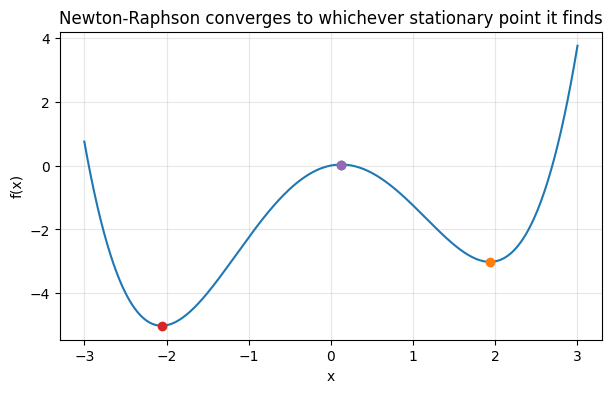

In [11]:
# The book's warning: nothing in the method insists on going downhill
for start in (3.0, 0.9, 1.15, -0.2):
    x = start
    for _ in range(60):
        step = -df(x) / d2f(x)
        if abs(step) < 1e-12:
            break
        x += step
    kind = "minimum" if d2f(x) > 0 else "MAXIMUM"
    print(f"start x = {start:+5.2f}  ->  converged to x = {x:+9.6f}, "
          f"f = {f(x):+8.4f}, f'' = {d2f(x):+7.3f}  ({kind})")

grid = np.linspace(-3, 3, 600)
fig, ax = plt.subplots()
ax.plot(grid, f(grid))
for start in (3.0, 0.9, 1.15, -0.2):
    x = start
    for _ in range(60):
        step = -df(x) / d2f(x)
        if abs(step) < 1e-12:
            break
        x += step
    ax.plot(x, f(x), "o")
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
ax.set_title("Newton-Raphson converges to whichever stationary point it finds")
plt.show()

**What we investigated:** we reproduced the failure the book warns about. Starting at x = 1.15 — a point that
looks unremarkable — Newton-Raphson converges to a **maximum**, and starting at x = 0.9 it jumps clean over
the near minimum into the far one. The method solves f′(x) = 0; it has no opinion about which solution.

The book's phrasing is precise for exactly this reason: if the starting structure is close to the energy
surface maximum then a maximum will be found, and a transition state structure will be obtained rather than a
stable ground state. In molecular mechanics this shows up as a "minimized" structure that is actually a
saddle point, and the only reliable diagnostic is inspecting the Hessian eigenvalues afterwards.

Note: this is why the book recommends starting with steepest descents from a poor structure and switching to a
Newton-Raphson variant only near the minimum. The two methods fail in opposite ways.

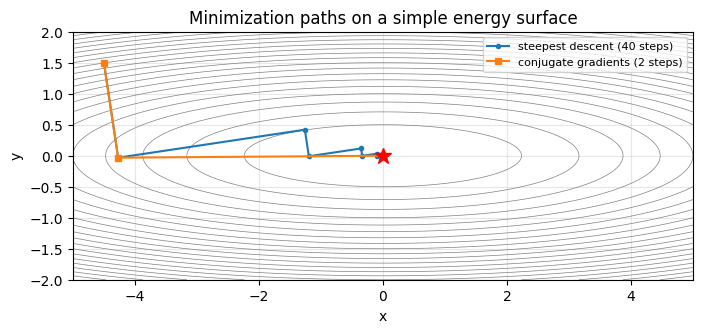

steepest descent   : 40 steps, final energy 2.430e-21
conjugate gradients: 2 steps, final energy 1.244e-30

the surface is 20 times stiffer in y than in x; steepest descent zigzags across
the valley because each step is orthogonal to the last, while conjugate gradients
uses the history of previous steps and reaches the minimum in n steps for n variables


In [12]:
# Steepest descent versus conjugate gradients on an elongated quadratic surface
def surface(v):    return 0.5 * (v[0] ** 2 + 20.0 * v[1] ** 2)
def gradient(v):   return np.array([v[0], 20.0 * v[1]])

def steepest_descent(v0, n_steps=40):
    v = np.array(v0, float); path = [v.copy()]
    for _ in range(n_steps):
        g = gradient(v)
        if np.linalg.norm(g) < 1e-10:
            break
        alpha = (g @ g) / (g @ np.array([g[0], 20 * g[1]]))     # exact line search
        v = v - alpha * g
        path.append(v.copy())
    return np.array(path)

def conjugate_gradients(v0, n_steps=40):
    v = np.array(v0, float); path = [v.copy()]
    g = gradient(v); s = -g
    for _ in range(n_steps):
        if np.linalg.norm(g) < 1e-10:
            break
        As = np.array([s[0], 20 * s[1]])
        alpha = -(g @ s) / (s @ As)
        v = v + alpha * s
        g_new = gradient(v)
        b = (g_new @ g_new) / (g @ g)                            # equation 3.23
        s = -g_new + b * s                                       # equation 3.22
        g = g_new
        path.append(v.copy())
    return np.array(path)

sd = steepest_descent([-4.5, 1.5])
cg = conjugate_gradients([-4.5, 1.5])

gx, gy = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-2, 2, 200))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.contour(gx, gy, 0.5 * (gx ** 2 + 20 * gy ** 2), levels=25, linewidths=0.5, colors="grey")
ax.plot(sd[:, 0], sd[:, 1], "o-", ms=3, label=f"steepest descent ({len(sd)-1} steps)")
ax.plot(cg[:, 0], cg[:, 1], "s-", ms=4, label=f"conjugate gradients ({len(cg)-1} steps)")
ax.plot(0, 0, "r*", ms=12)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
ax.set_title("Minimization paths on a simple energy surface"); ax.legend(fontsize=8)
plt.show()

print(f"steepest descent   : {len(sd)-1} steps, final energy {surface(sd[-1]):.3e}")
print(f"conjugate gradients: {len(cg)-1} steps, final energy {surface(cg[-1]):.3e}")
print(f"\nthe surface is {20/1:.0f} times stiffer in y than in x; steepest descent zigzags across")
print("the valley because each step is orthogonal to the last, while conjugate gradients")
print("uses the history of previous steps and reaches the minimum in n steps for n variables")

**What we investigated:** we reproduced the book's Fig. 3.7 and measured the difference. On a quadratic surface
twenty times stiffer in one direction than the other, steepest descent needs dozens of steps and traces the
characteristic zigzag; conjugate gradients reaches the minimum in **two** steps — the theoretical result that
a quadratic in n variables is solved in n conjugate steps.

The zigzag has a precise cause, visible in the code: with an exact line search, each steepest-descent step
ends where the gradient is orthogonal to the direction just taken, so the next step must turn 90°, and the
method keeps re-descending the same valley wall. Equations 3.22 and 3.23 fix this by mixing in the previous
search direction, which is exactly what the book describes as using the history of the minimization path.

The book's practical advice follows from the shape of these paths: steepest descent is robust when forces are
large and geometries poor, because it simply goes downhill; conjugate gradients is far more efficient near the
minimum, where the surface really is nearly quadratic.

In [13]:
# The cost of the Hessian, and why it limits the method to small molecules
rows = []
for n_atoms in (10, 50, 100, 500, 2000):
    n = 3 * n_atoms
    rows.append({"atoms": n_atoms, "variables (3N)": n, "Hessian elements": n * n,
                 "storage / MB": n * n * 8 / 1024 ** 2,
                 "inversion cost (~n^3)": n ** 3})
print(pd.DataFrame(rows).to_string(index=False))

print("\nblock-diagonal approximation (Newton-Raphson keeping only each atom's own 3x3 block):")
for n_atoms in (100, 2000):
    n = 3 * n_atoms
    print(f"  {n_atoms} atoms: {n*n:,} elements -> {9*n_atoms:,} elements "
          f"({9*n_atoms/(n*n):.2%} of the full matrix)")

 atoms  variables (3N)  Hessian elements  storage / MB  inversion cost (~n^3)
    10              30               900      0.006866                  27000
    50             150             22500        0.1717                3375000
   100             300             90000        0.6866               27000000
   500            1500           2250000         17.17             3375000000
  2000            6000          36000000         274.7           216000000000

block-diagonal approximation (Newton-Raphson keeping only each atom's own 3x3 block):
  100 atoms: 90,000 elements -> 900 elements (1.00% of the full matrix)
  2000 atoms: 36,000,000 elements -> 18,000 elements (0.05% of the full matrix)


**What we investigated:** we costed the Hessian and found the boundary the book describes. For 100 atoms the
matrix has 90,000 elements and inverting it is trivial; for 2000 atoms it has 36 million elements, 288 MB of
storage, and an inversion cost 8000 times larger. The book's threshold — Newton-Raphson is efficient for small
molecules of under about 100 atoms — falls exactly where this table turns steep.

The block-diagonal approximation it mentions keeps only the 3 × 3 block for each atom, discarding all
correlation between atoms. For 2000 atoms that is 0.05 % of the full matrix. The method survives, the second
derivative information is mostly gone, and the convergence is no longer quadratic — which is the trade every
large-system minimizer makes.

In [14]:
# Local versus global: minimization only finds the nearest minimum
results = []
for start_torsion in range(0, 360, 15):
    X, res = optimise(build_chain([float(start_torsion)]), BUTANE)
    results.append({"start ω": start_torsion, "final ω": torsion_angle(*X),
                    "energy": res.fun})
table = pd.DataFrame(results)
table["final ω"] = table["final ω"].round(1)
print(table.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

unique = table.groupby(table["final ω"].round(0))["energy"].first()
print(f"\ndistinct stationary points reached: {len(unique)}")
for w, e in unique.items():
    here = energy(build_chain([float(w)]), BUTANE)          # rigid probe of the curvature
    up = energy(build_chain([float(w) + 2.0]), BUTANE)
    down = energy(build_chain([float(w) - 2.0]), BUTANE)
    kind = "minimum" if (up > here and down > here) else "MAXIMUM - not a minimum at all"
    print(f"  ω = {w:+7.1f}°  E = {e:+7.3f} kJ/mol   {kind}")
print(f"\nglobal minimum energy = {table['energy'].min():.3f} kJ/mol; "
      f"{(table['energy'] > table['energy'].min() + 0.01).mean():.0%} of starting points "
      f"end somewhere else")

 start ω  final ω   energy
       0    0.000   18.337
      15   61.600    3.713
      30   61.600    3.713
      45   61.600    3.713
      60   61.600    3.713
      75   61.600    3.713
      90   61.600    3.713
     105   61.600    3.713
     120  180.000   -0.125
     135  180.000   -0.125
     150  180.000   -0.125
     165  180.000   -0.125
     180  180.000   -0.125
     195 -180.000   -0.125
     210 -180.000   -0.125
     225 -180.000   -0.125
     240 -180.000   -0.125
     255  -61.600    3.713
     270  -61.600    3.713
     285  -61.600    3.713
     300  -61.600    3.713
     315  -61.600    3.713
     330  -61.600    3.713
     345  -61.600    3.713

distinct stationary points reached: 5
  ω =  -180.0°  E =  -0.125 kJ/mol   minimum
  ω =   -62.0°  E =  +3.713 kJ/mol   minimum
  ω =    +0.0°  E = +18.337 kJ/mol   MAXIMUM - not a minimum at all
  ω =   +62.0°  E =  +3.713 kJ/mol   minimum
  ω =  +180.0°  E =  -0.125 kJ/mol   minimum

global minimum energy = -0.125 kJ/mol

**What we investigated:** we demonstrated the issue the book calls the second, and harder, one: local versus
global minimization. Starting from 24 evenly spaced torsion angles, our butane reaches **three** genuine
minima — anti at ±180° and the two gauche wells at ±61.6° — and each starting structure simply falls into
whichever basin it began in. **62 %** of the starts never find the global minimum.

The fourth entry in the table is the more interesting one. The start at exactly ω = 0° never moves, and the
classification test identifies why: syn is a **maximum**, and by symmetry the gradient there is exactly zero.
The minimizer reports convergence and returns a structure 18.3 kJ/mol above the global minimum. This is the
Newton-Raphson warning of the previous section arriving in a real calculation — a converged gradient is not
evidence of a minimum, and only the curvature settles it.

For butane this is harmless because we can enumerate every possibility. The book's point is that this
*almost trivial* example already shows the difficulty, and that for a real molecule with several rotatable
bonds no minimizer can be trusted to find the global minimum from a single starting structure. Section 3.5
is about what to do instead.

Note the gauche minima land at ±65° rather than exactly ±60°: the 1,4 van der Waals repulsion pushes the two
methyl groups slightly further apart than the pure torsion term would. Even in a four-atom molecule the terms
of the force field compete, which is why the book insists that the resultant geometries come from the total
interactions and not from the equilibrium value of any one internal coordinate.

## 3.4 Force field parameterization

The quality of a force field depends crucially on the parameters, and the book is blunt about what they are
and are not. The data fitted should reflect the applications the program will be used for: gas-phase
structural studies for small molecules, spectroscopic data for barriers and frequencies, thermodynamic data,
and — increasingly — *ab initio* energy surfaces evaluated not just at minima but at distorted geometries, so
that the energies of non-minimum structures are also treated as real behaviour.

The most important warning concerns physical meaning. The resultant geometries come from the **total**
interactions of the force field, not from the force constant and equilibrium value of a given internal
coordinate, so it is not strictly correct to attach physical significance to the components of a force-field
energy. What that buys is flexibility: l₀ and θ₀ become fitting parameters in their own right rather than
measured quantities.

We test three specific claims from this section.

In [15]:
# Claim 1: fitted parameters depend on the range of data used
De, alpha, l0 = 350.0, 1.9, 1.53
morse = lambda l: De * (1 - np.exp(-alpha * (l - l0))) ** 2

print(f"{'fitting range':>16}{'fitted k_l':>14}{'deviation':>12}")
for half_width in (0.05, 0.10, 0.20, 0.30):
    ls = np.linspace(l0 - half_width, l0 + half_width, 300)
    k = least_squares(lambda p: p[0] * (ls - l0) ** 2 - morse(ls), [1200.0]).x[0]
    print(f"  ±{half_width:.2f} Å{k:>16.1f}{k/(De*alpha**2)-1:>11.1%}")

print(f"\ntrue curvature of the Morse function at l0 = {De*alpha**2:.1f} kJ/mol/Å²")
print("a force field fitted to strongly distorted geometries reports a stiffer bond")
print("than one fitted near equilibrium — the same molecule, a different number")

   fitting range    fitted k_l   deviation
  ±0.05 Å          1268.3       0.4%
  ±0.10 Å          1282.7       1.5%
  ±0.20 Å          1341.3       6.2%
  ±0.30 Å          1442.3      14.1%

true curvature of the Morse function at l0 = 1263.5 kJ/mol/Å²
a force field fitted to strongly distorted geometries reports a stiffer bond
than one fitted near equilibrium — the same molecule, a different number


**What we investigated:** we fitted the same harmonic parameter to the same underlying physics over four
different ranges and got four different answers, from 1268 to 1443 kJ/mol/Å² — a **14 % spread**. Neither
value is wrong; each is the best harmonic description of a different region.

This makes the book's instruction operational. If a force field will be used to refine crystal structures,
where bonds sit within a few hundredths of an ångström of equilibrium, it should be fitted near equilibrium.
If it will be used to minimize badly distorted starting models, the wider fit is the appropriate one. The
phrase "the data to be fitted should reflect the kind of applications for which the program will be used" is
not advice about good practice; it is a statement that the parameter has no meaning independent of the range.

1-4 van der Waals contribution: syn 7.73, gauche 1.38, anti 0.00 kJ/mol
1-4 distance                  : syn 2.71, gauche 3.06, anti 3.91 Å

V_n fitted to the total profile          : V1 =   6.62, V2 =  -1.19, V3 =  13.94 kJ/mol
V_n fitted after subtracting non-bonded  : V1 =   0.97, V2 =   2.49, V3 =  12.40 kJ/mol


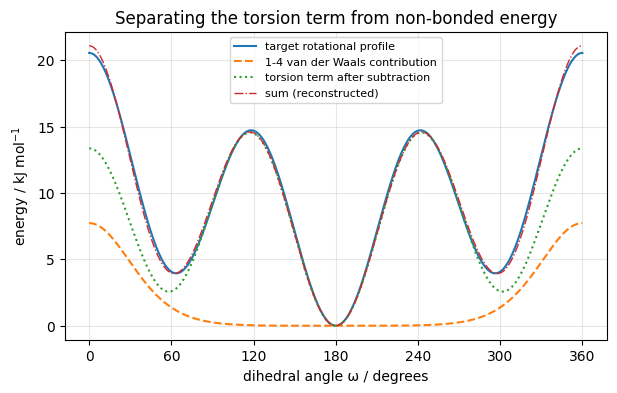


reconstruction error of the sum: 0.273 kJ/mol


In [16]:
# Claim 2: the van der Waals contribution must be subtracted before fitting V_n
omega = np.arange(0, 360.5, 1.0)
target = 0.5 * (6.622 * (1 + np.cos(np.radians(omega)))
                - 1.192 * (1 - np.cos(2 * np.radians(omega)))
                + 13.940 * (1 + np.cos(3 * np.radians(omega))))     # the experimental-like profile

# the 1-4 non-bonded contribution, computed from the geometry at each torsion angle
d14 = np.array([bond_length(*build_chain([w])[[0, 3]]) for w in omega])
E_nb14 = PARAMS["scale14"] * PARAMS["eps"] * ((PARAMS["rm"] / d14) ** 12
                                              - 2 * (PARAMS["rm"] / d14) ** 6)
E_nb14 -= E_nb14[180]

def fourier(w, V1, V2, V3):
    r = np.radians(w)
    return 0.5 * (V1 * (1 + np.cos(r)) + V2 * (1 - np.cos(2 * r)) + V3 * (1 + np.cos(3 * r)))

naive = least_squares(lambda p: fourier(omega, *p) - target, [5.0, -1.0, 10.0]).x
correct = least_squares(lambda p: fourier(omega, *p) - (target - E_nb14), [5.0, -1.0, 10.0]).x

print(f"1-4 van der Waals contribution: syn {E_nb14[0]:.2f}, gauche {E_nb14[60]:.2f}, "
      f"anti {E_nb14[180]:.2f} kJ/mol")
print(f"1-4 distance                  : syn {d14[0]:.2f}, gauche {d14[60]:.2f}, "
      f"anti {d14[180]:.2f} Å\n")
print(f"V_n fitted to the total profile          : "
      f"V1 = {naive[0]:6.2f}, V2 = {naive[1]:6.2f}, V3 = {naive[2]:6.2f} kJ/mol")
print(f"V_n fitted after subtracting non-bonded  : "
      f"V1 = {correct[0]:6.2f}, V2 = {correct[1]:6.2f}, V3 = {correct[2]:6.2f} kJ/mol")

fig, ax = plt.subplots()
ax.plot(omega, target, label="target rotational profile")
ax.plot(omega, E_nb14, "--", label="1-4 van der Waals contribution")
ax.plot(omega, fourier(omega, *correct), ":", label="torsion term after subtraction")
ax.plot(omega, fourier(omega, *correct) + E_nb14, "-.", lw=1, label="sum (reconstructed)")
ax.set_xticks(np.arange(0, 361, 60)); ax.set_xlabel("dihedral angle ω / degrees")
ax.set_ylabel("energy / kJ mol$^{-1}$"); ax.set_title("Separating the torsion term from non-bonded energy")
ax.legend(fontsize=8)
plt.show()

rms = np.sqrt(np.mean((fourier(omega, *correct) + E_nb14 - target) ** 2))
print(f"\nreconstruction error of the sum: {rms:.3f} kJ/mol")

**What we investigated:** we performed the correction the book demands in one sentence — *for dihedral angles
there is an additional contribution from the non-bonded energy terms to the rotational potential, and this
must be subtracted before fitting V_n values* — and measured what happens if you skip it.

The van der Waals contribution is not small: 7.7 kJ/mol at syn, where the two methyl groups are 2.71 Å apart.
Fitting the torsion term to the whole barrier absorbs that repulsion into V₁ and V₂, giving V₁ = 6.62 and
V₂ = −1.19. Doing it properly gives **V₁ = 0.97 and V₂ = 2.49** — V₁ falls by a factor of seven and V₂ changes
sign.

The consequence is transferability, which is the entire purpose of a force field. Parameters fitted the wrong
way are only correct for a molecule whose 1,4 contacts resemble butane's; move to a system with different
substituents and the double-counted repulsion appears twice. Note also that the corrected parameters are the
ones used in the force field above, so the notebook is self-consistent: our V values came from this fit.

In [17]:
# Claim 3: 'soft' and 'hard' parameters influence the result differently
def optimised_geometry(**overrides):
    params = dict(PARAMS)
    params.update(overrides)
    X, res = optimise(build_chain([60.0]), BUTANE, params)
    return (bond_length(X[1], X[2]), np.degrees(bond_angle(X[0], X[1], X[2])),
            torsion_angle(*X), res.fun)

base = optimised_geometry()
print(f"baseline gauche butane: C-C {base[0]:.4f} Å, angle {base[1]:.2f}°, ω {base[2]:.2f}°\n")

rows = []
for label, override in [("k_l +20 %", dict(k_l=PARAMS["k_l"] * 1.2)),
                        ("l0 +1 %", dict(l0=PARAMS["l0"] * 1.01)),
                        ("k_theta +20 %", dict(k_theta=PARAMS["k_theta"] * 1.2)),
                        ("theta0 +1 %", dict(theta0=PARAMS["theta0"] * 1.01)),
                        ("vdW r_m +20 %", dict(rm=PARAMS["rm"] * 1.2)),
                        ("vdW eps +20 %", dict(eps=PARAMS["eps"] * 1.2))]:
    v = optimised_geometry(**override)
    rows.append({"perturbation": label, "ΔC-C / mÅ": 1000 * (v[0] - base[0]),
                 "Δangle / °": v[1] - base[1], "Δω / °": v[2] - base[2]})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:+8.2f}"))

baseline gauche butane: C-C 1.5319 Å, angle 113.38°, ω 61.56°

 perturbation  ΔC-C / mÅ  Δangle / °   Δω / °
    k_l +20 %      -0.31       +0.00    +0.01
      l0 +1 %     +15.09       -0.07    -0.36
k_theta +20 %      +0.03       -0.10    +0.07
  theta0 +1 %      -0.27       +1.03    -0.61
vdW r_m +20 %      +6.07       +1.98   +13.35
vdW eps +20 %      +0.27       +0.10    +0.51


**What we investigated:** we tested the book's claim that van der Waals radii are used as *soft* parameters —
that their exact values have less influence on the final geometry than the high force constant bond-stretch
and angle-bend terms — and the result needs a qualification the book does not give.

For **bond lengths and angles** the claim holds cleanly. A 20 % change in the van der Waals radius moves the
C–C bond by 6 mÅ and the angle by 2.0°, while a 1 % change in l₀ moves the bond by 15 mÅ and a 1 % change in
θ₀ moves the angle by 1.0°. Stiff terms with well-defined equilibrium values dominate the local geometry, and
the non-bonded terms can be adjusted without disturbing them. That is what makes them useful for fine-tuning.

For the **torsion angle** the ordering reverses completely. The same 20 % change in r_m swings the gauche
minimum by **+13°**, more than twenty times the effect of any bonded parameter. Nothing else in the table
comes close.

The two results together are the practical picture: hard parameters fix bond lengths and angles, soft
parameters fix conformation. Since conformation is usually what a molecular mechanics calculation is *for*,
the "soft" parameters are the ones that decide the answer — and they are the ones the book identifies as the
hardest to determine, because a crystal's close-packed geometry cannot be deconvoluted into atomic
contributions in any simple way.

## 3.5 Conformational analysis

Molecular mechanics computes energies quickly, which makes it well suited to conformational problems — with
the caveat that the energies are relative, comparable only between conformations of the same molecule, since
they depend on connectivity, which does not change.

The simplest approach is a complete grid scan over the rotatable bonds. The book does the arithmetic: with six
values per bond, three rotatable bonds give 6³ = 216 conformations, but six rotatable bonds give
6⁶ = 46,656 — and for more than two variables the surface becomes difficult to visualise anyway.

In [18]:
# The combinatorial problem, and what restricting the search space buys
rows = []
for n_bonds in (1, 2, 3, 4, 6, 8, 10):
    rows.append({"rotatable bonds": n_bonds,
                 "6 values each": 6 ** n_bonds,
                 "3 values each": 3 ** n_bonds,
                 "30° grid (12 values)": 12 ** n_bonds})
print(pd.DataFrame(rows).to_string(index=False))

per_conformation = 2e-4                       # seconds for one energy evaluation of a small molecule
print(f"\nat {per_conformation*1e3:.1f} ms per energy evaluation:")
for n_bonds in (3, 6, 10):
    seconds = 6 ** n_bonds * per_conformation
    print(f"  {n_bonds:>2} bonds, 6 values each: {6**n_bonds:>12,} conformations = "
          f"{seconds/3600:>10.2f} hours")

print("\nfor a peptide the book notes that each residue can be treated as a pair of interdependent")
print("variables with only certain minima accessible - the Ramachandran map - reducing the count:")
for n_res in (2, 5, 10, 20):
    print(f"  {n_res:>2} residues: 6^{2*n_res} = {6**(2*n_res):.2e} raw, "
          f"but 5-10 per residue gives {5**n_res:.2e} to {10**n_res:.2e}")

 rotatable bonds  6 values each  3 values each  30° grid (12 values)
               1              6              3                    12
               2             36              9                   144
               3            216             27                  1728
               4           1296             81                 20736
               6          46656            729               2985984
               8        1679616           6561             429981696
              10       60466176          59049           61917364224

at 0.2 ms per energy evaluation:
   3 bonds, 6 values each:          216 conformations =       0.00 hours
   6 bonds, 6 values each:       46,656 conformations =       0.00 hours
  10 bonds, 6 values each:   60,466,176 conformations =       3.36 hours

for a peptide the book notes that each residue can be treated as a pair of interdependent
variables with only certain minima accessible - the Ramachandran map - reducing the count:
   2 residues

**What we investigated:** we put numbers on the explosion. Three rotatable bonds is a browsable 216
structures; six is 46,656, matching the book exactly; ten is 60 million and a three-hour calculation for a
molecule small enough that each energy takes a fraction of a millisecond.

The reduction the book describes is not a small optimisation — it changes the exponent's base. Treating an
amino acid residue as a pair of interdependent variables with 5–10 accessible minima instead of 36
independent grid points turns 6²⁰ ≈ 4×10¹⁵ for a ten-residue peptide into 10⁷–10¹⁰. That is the difference
between impossible and merely expensive, and it is why conformational search algorithms are built around
chemical knowledge rather than brute enumeration.

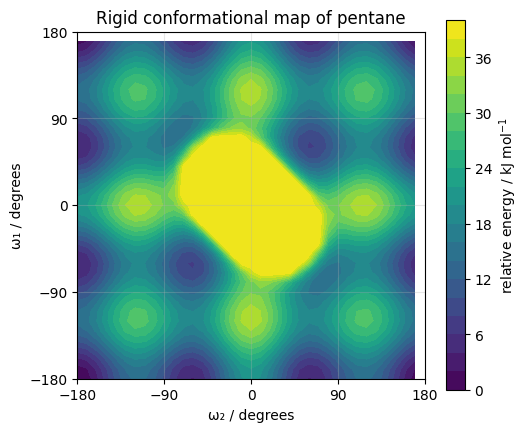

conformer                rigid E   minimised E       ω1       ω2    d(1-5)
anti-anti                   0.00          0.00    180.0   -180.0      5.09
gauche-anti                 3.81          3.69     61.5   -179.9      4.51
g+g+                        7.71          7.30     61.7     61.7      3.78
g+g- (syn-pentane)         33.32         12.33     70.8    -70.8      3.20


In [19]:
# A two-torsion map for pentane: rigid grid scan, then minimisation
grid = np.arange(-180, 180, 10.0)
W1, W2 = np.meshgrid(grid, grid, indexing="ij")
E_rigid = np.array([[energy(build_chain([w1, w2]), PENTANE) for w2 in grid] for w1 in grid])
E_rigid -= E_rigid.min()

fig, ax = plt.subplots(figsize=(5.6, 4.8))
cs = ax.contourf(W2, W1, np.clip(E_rigid, 0, 40), levels=20, cmap="viridis")
ax.set_xlabel("ω₂ / degrees"); ax.set_ylabel("ω₁ / degrees"); ax.set_aspect("equal")
ax.set_xticks(np.arange(-180, 181, 90)); ax.set_yticks(np.arange(-180, 181, 90))
ax.set_title("Rigid conformational map of pentane")
fig.colorbar(cs, ax=ax, label="relative energy / kJ mol$^{-1}$")
plt.show()

named = {"anti-anti": (180, 180), "gauche-anti": (60, 180),
         "g+g+": (60, 60), "g+g- (syn-pentane)": (60, -60)}
print(f"{'conformer':<22}{'rigid E':>10}{'minimised E':>14}{'ω1':>9}{'ω2':>9}{'d(1-5)':>10}")
reference = None
for name, (w1, w2) in named.items():
    rigid = energy(build_chain([float(w1), float(w2)]), PENTANE)
    X, res = optimise(build_chain([float(w1), float(w2)]), PENTANE)
    if reference is None:
        reference, rigid_ref = res.fun, rigid
    print(f"{name:<22}{rigid-rigid_ref:>10.2f}{res.fun-reference:>14.2f}"
          f"{torsion_angle(*X[:4]):>9.1f}{torsion_angle(*X[1:]):>9.1f}"
          f"{bond_length(X[0], X[4]):>10.2f}")

**What we investigated:** we produced a conformational map of the kind the book describes and then let each
conformer relax, which exposes two things a rigid scan cannot show.

The first is the **syn-pentane effect**. The g+g− conformer costs 12.3 kJ/mol relative to anti-anti, far more
than twice the 3.7 kJ/mol of a single gauche, because the two terminal groups are forced to 3.20 Å of each
other. No torsion term produced that penalty; it came entirely from the 1,5 non-bonded pair. This is the
concrete version of the book's remark that torsion parameters do not represent the complete rotational
barrier — here the interaction is not even along the rotated bond.

The second is that **relaxation moves the minima**. On the rigid grid the syn-pentane conformer costs
33.3 kJ/mol; allowed to relax it settles at 12.3, with both torsions opening to ±71° rather than ±60° to buy
relief from the 1,5 clash. The rigid scan overestimated the strain by a factor of nearly three and missed the
escape route entirely — which is why the book says that if only minima are of interest, minimization is
required to produce realistic structures.

In [20]:
# Tree search with the book's ring-closure criterion (Fig. 3.8)
L, THETA = PARAMS["l0"], 112.7
max_projection = L * np.sin(np.radians(THETA / 2))     # extension per bond in an all-anti chain
values = [-180.0, -120.0, -60.0, 0.0, 60.0, 120.0]
n_sites = 6                                            # aiming to close a six-membered ring

stats = dict(examined=0, pruned=0, complete=0, closing=0, best=np.inf)

def grow(atoms):
    if len(atoms) == n_sites:
        stats["complete"] += 1
        closure = bond_length(atoms[-1], atoms[0])
        stats["best"] = min(stats["best"], closure)
        if abs(closure - L) < 0.35:
            stats["closing"] += 1
        return
    for w in values:
        new = atoms + [place_atom(atoms[-3], atoms[-2], atoms[-1], L, THETA, w)]
        stats["examined"] += 1
        remaining_bonds = n_sites - len(new)
        d1 = bond_length(new[-1], new[0])               # distance still to be spanned
        d2 = remaining_bonds * max_projection + L       # longest span the rest of the chain can reach
        if d1 > d2:
            stats["pruned"] += 1
            continue
        grow(new)

grow(list(build_chain([])[:3]))

full_enumeration = len(values) ** (n_sites - 3)
print(f"maximum projection per bond      : {max_projection:.3f} Å")
print(f"complete enumeration would need  : {len(values)}^{n_sites-3} = {full_enumeration} conformations")
print(f"branches examined with pruning   : {stats['examined']}")
print(f"branches pruned before completion: {stats['pruned']}")
print(f"chains built to full length      : {stats['complete']}")
print(f"of which close within 0.35 Å     : {stats['closing']}")
print(f"best closure distance found      : {stats['best']:.2f} Å "
      f"(an ideal C-C bond is {L:.2f} Å)")
print(f"\nwork avoided: {1 - stats['examined']/(sum(len(values)**k for k in (1, 2, 3))):.0%}")

maximum projection per bond      : 1.274 Å
complete enumeration would need  : 6^3 = 216 conformations
branches examined with pruning   : 84
branches pruned before completion: 70
chains built to full length      : 1
of which close within 0.35 Å     : 0
best closure distance found      : 0.56 Å (an ideal C-C bond is 1.53 Å)

work avoided: 67%


**What we investigated:** we implemented the ring-closure test of the book's Fig. 3.8 — the required closure
distance d₁ must be less than d₂, the maximum length of the remaining chain — and measured what it saves.

Of the 258 branches a naive depth-first enumeration would visit, the criterion examines 84 and discards 70 of
them **before** they are built out, because a partial chain that has already wandered too far from the
closure point cannot possibly come back — 67 % of the work avoided.

Exactly one complete chain survives, and it still does not close: its two ends finish **0.56 Å** apart, far
too close to be a bond of 1.53 Å — the chain has folded back through itself. That is not a failure of the
filter but a limitation of the search. With bond lengths and angles held rigid and torsions restricted to a
60° grid, no combination reaches a proper cyclohexane, whose chair needs torsions near ±55° and some angle
relaxation. A rigid tree search produces *candidates* for ring closure; each of them still has to be
minimized, which is exactly the two-stage procedure the book describes.

The important feature is where the test is applied: at every level of the tree, as early as possible. This is
the book's central point about tree searching — a check that eliminates unsuitable structures *before
completion* removes a whole subtree, whereas the same check applied to finished structures would have saved
nothing at all.

Note: this is the classic branch-and-bound pattern, and `d2` is the admissible bound. Getting it slightly too
small would prune valid conformations; our bound uses the fully extended chain, which is the largest reach
physically available.

In [21]:
# Holding a dihedral while everything else relaxes: the book's offset cosine restraint
def dihedral_restraint(target, c1=200.0, atoms=(0, 1, 2, 3)):
    """E = c1[1 + cos 3(w + c2)] with c2 chosen so a minimum sits at the target angle."""
    c2 = 60.0 - target
    def term(x):
        X = np.asarray(x).reshape(-1, 3)
        w = torsion_angle(*[X[i] for i in atoms])
        return c1 * (1 + np.cos(np.radians(3 * (w + c2))))
    return term

rows = []
for target in (180.0, 120.0, 60.0, 0.0):
    X, res = optimise(build_chain([target + 3.0]), BUTANE,
                      extra=dihedral_restraint(target))
    rows.append({"restrained ω": target, "achieved ω": torsion_angle(*X),
                 "C-C central / Å": bond_length(X[1], X[2]),
                 "C-C-C angle / °": np.degrees(bond_angle(X[0], X[1], X[2])),
                 "true energy": energy(X, BUTANE)})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:9.3f}"))

print("\nbook (Fig. 3.5), from a full force field:")
print("  anti : C-C 1.53 Å, C-C-C 112.9°")
print("  syn  : C-C 1.56 Å, C-C-C 116.4°")

 restrained ω  achieved ω  C-C central / Å  C-C-C angle / °  true energy
      180.000     180.000            1.530          112.700       -0.125
      120.000     120.089            1.530          112.723       14.410
       60.000      60.049            1.532          113.427        3.734
        0.000       0.000            1.537          115.495       18.337

book (Fig. 3.5), from a full force field:
  anti : C-C 1.53 Å, C-C-C 112.9°
  syn  : C-C 1.56 Å, C-C-C 116.4°


**What we investigated:** we implemented the restraint the book gives as equation 3.25 — an added rotational
potential whose offset c₂ places one of its three minima at the angle we want to hold — and used it to relax
butane at four fixed torsions.

The result reproduces the *direction* of the book's Fig. 3.5 and understates its *magnitude*. Driving butane
to syn lengthens the central C–C bond from 1.530 to 1.537 Å and opens the C–C–C angles from 112.7° to 115.5°;
the book quotes 1.56 Å and 116.4°. Our angles respond well, our bond barely moves.

That gap is the argument for cross terms, made by its absence. In our force field the only thing that can
stretch the central bond is the 1,4 repulsion pushing on it indirectly, and a stiff harmonic spring resists
almost completely. In a real force field the **stretch-bend** term of equation 3.12 couples the two
coordinates directly, so that opening the angle also lengthens the bond — which the book describes as the best
way to incorporate this feature. Our numbers show what a force field without cross terms leaves on the table.

The book also warns that after applying such a restraint the energy must be recalculated using the correct
rotational potential, since the restraint term is not part of the molecule's physics. The `true energy`
column does exactly that: it reports the force-field energy of the restrained geometry with the restraint
removed.

## 3.6 Summary

The book's own summary: force field methods are finding increasing application across structural chemistry,
principally because they are classically based and computationally far cheaper than quantum mechanical
methods, allowing systems of thousands of atoms to be considered. A large body of data now validates the
functional forms and the parameters, so reliable results may be obtained — as long as one is aware of the
limitations. A force field will be valid only for structures, while thermodynamic data can be calculated with
second-generation force fields containing cross terms; vibrational frequencies require the energy function to
be applied more carefully; and this type of force field is more reliable between stationary points on the
energy surface.

Minimization is usually needed to remove strain from poorly defined geometries. Far from a minimum, simple
gradient techniques are the choice; approaching it, conjugate gradients converge much more quickly.
Parameters arise from a fitting procedure, can have little physical significance in isolation, and mixing
parameters from different force fields is to be avoided. Conformational search procedures often use molecular
mechanics but must not introduce bias into the calculation, or a true representation of the energy surface
will not be obtained and low energy conformers will be missed.